XGB model that trains on the full data set with all input features and selects the top 15 features via the integrated feature importance metrics, then optimises with optuna.

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
import sys
sys.path.append('../..')  # goes up from XGB_Classifier/ to Electron_Project/
from Modules.Utils import full_feature_data_preprocess  
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.metrics import f1_score
import pandas as pd



In [5]:
x_train, x_test, y_train, y_test = full_feature_data_preprocess('/Users/prometheus/Documents/Python/Electron_Project/Data/AppML_InitialProject_train.h5', 'p_Truth_isElectron', test_size=0.2)

Dataset loaded from /Users/prometheus/Documents/Python/Electron_Project/Data/AppML_InitialProject_train.h5 with shape (180000, 140)
Target variable 'p_Truth_isElectron' class distribution:
p_Truth_isElectron
0    0.79
1    0.21
Name: proportion, dtype: float64
No missing values detected in the dataset.
Dropped 44 highly correlated features


In [6]:
#fit the model
parameters = {
    'n_estimators': 10000,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_lambda': 1,
    'eval_metric': 'logloss',
    'early_stopping_rounds': 10
}


model = XGBClassifier(**parameters)
model.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)])

print("Best iteration:", model.get_booster().best_iteration)

[0]	validation_0-logloss:0.44203	validation_1-logloss:0.44077
[1]	validation_0-logloss:0.39229	validation_1-logloss:0.39165
[2]	validation_0-logloss:0.35427	validation_1-logloss:0.35408
[3]	validation_0-logloss:0.32365	validation_1-logloss:0.32387
[4]	validation_0-logloss:0.29828	validation_1-logloss:0.29865
[5]	validation_0-logloss:0.27585	validation_1-logloss:0.27658
[6]	validation_0-logloss:0.25773	validation_1-logloss:0.25859
[7]	validation_0-logloss:0.24076	validation_1-logloss:0.24183
[8]	validation_0-logloss:0.22590	validation_1-logloss:0.22711
[9]	validation_0-logloss:0.21318	validation_1-logloss:0.21454
[10]	validation_0-logloss:0.20222	validation_1-logloss:0.20371
[11]	validation_0-logloss:0.19271	validation_1-logloss:0.19429
[12]	validation_0-logloss:0.18443	validation_1-logloss:0.18614
[13]	validation_0-logloss:0.17595	validation_1-logloss:0.17783
[14]	validation_0-logloss:0.16855	validation_1-logloss:0.17066
[15]	validation_0-logloss:0.16199	validation_1-logloss:0.16420
[1

In [7]:
#evaluate the model
y_pred = model.predict(x_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     28486
           1       0.95      0.92      0.94      7514

    accuracy                           0.97     36000
   macro avg       0.97      0.95      0.96     36000
weighted avg       0.97      0.97      0.97     36000

Confusion Matrix:
[[28148   338]
 [  602  6912]]
Accuracy Score: 0.9738888888888889


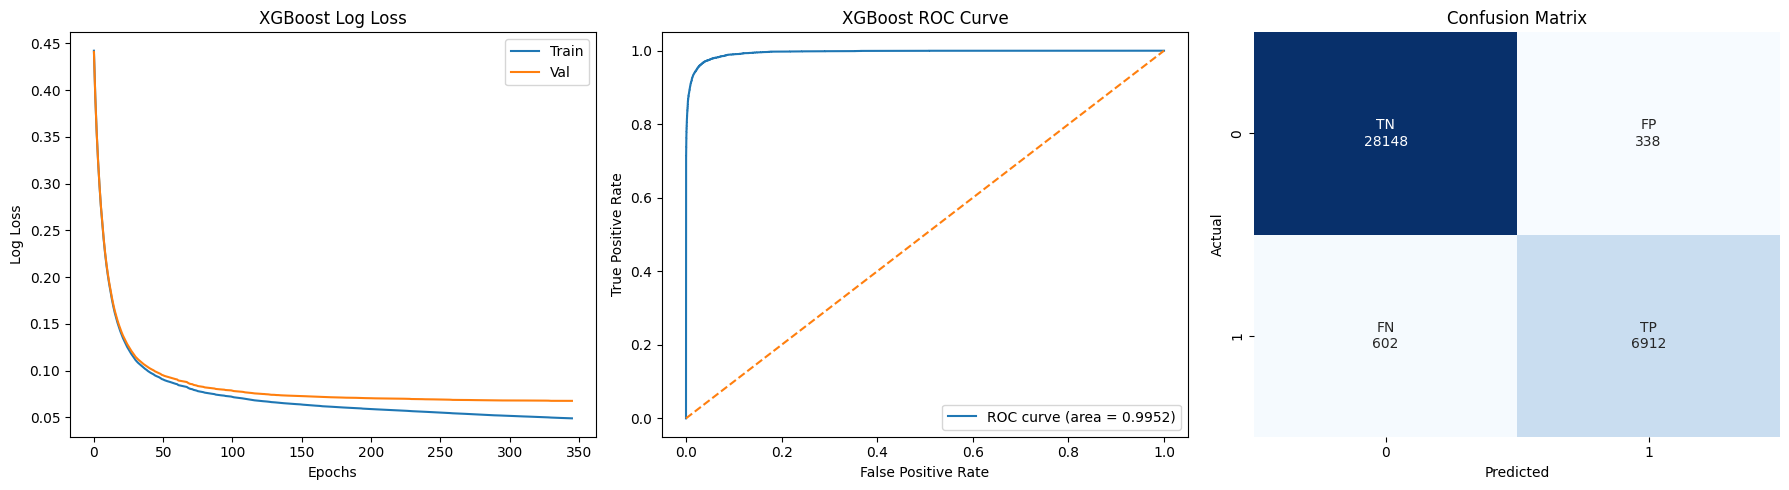

In [8]:
#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


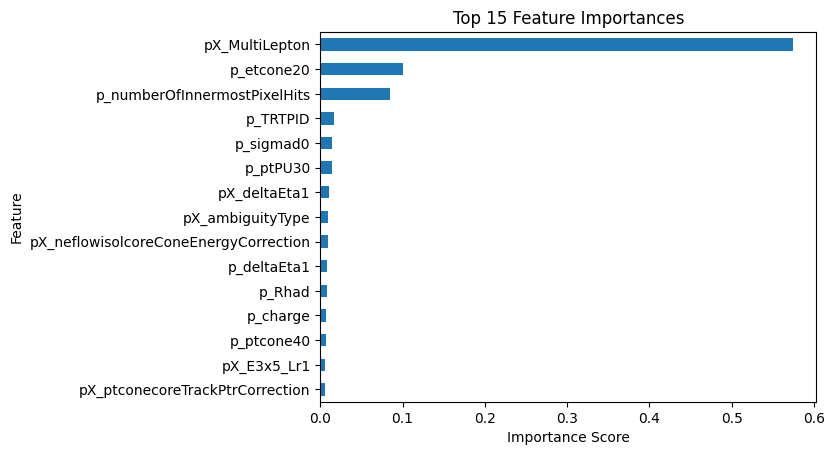

Top 15 features: ['pX_MultiLepton', 'p_etcone20', 'p_numberOfInnermostPixelHits', 'p_TRTPID', 'p_sigmad0', 'p_ptPU30', 'pX_deltaEta1', 'pX_ambiguityType', 'pX_neflowisolcoreConeEnergyCorrection', 'p_deltaEta1', 'p_Rhad', 'p_charge', 'p_ptcone40', 'pX_E3x5_Lr1', 'pX_ptconecoreTrackPtrCorrection']


In [ ]:
#plot top 15 feature importances
importances = model.feature_importances_
feature_names = x_train.columns
feat_importances = pd.Series(importances, index=feature_names)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis() 
plt.show()

#save to a list
feature_importance_list = feat_importances.nlargest(15).index.tolist()
print("Top 15 features:", feature_importance_list)

#save feature list to a text file
with open('/saved_models/XGB_CLASSIFY_INPUT_FEATURES.txt', 'w') as f:
    for feature in feature_importance_list:
        f.write(feature + '\n')



[0]	validation_0-logloss:0.44203	validation_1-logloss:0.44076
[1]	validation_0-logloss:0.39229	validation_1-logloss:0.39165
[2]	validation_0-logloss:0.35433	validation_1-logloss:0.35404
[3]	validation_0-logloss:0.32374	validation_1-logloss:0.32384
[4]	validation_0-logloss:0.29854	validation_1-logloss:0.29899
[5]	validation_0-logloss:0.27727	validation_1-logloss:0.27799
[6]	validation_0-logloss:0.25764	validation_1-logloss:0.25853
[7]	validation_0-logloss:0.24080	validation_1-logloss:0.24185
[8]	validation_0-logloss:0.22607	validation_1-logloss:0.22733
[9]	validation_0-logloss:0.21333	validation_1-logloss:0.21478
[10]	validation_0-logloss:0.20250	validation_1-logloss:0.20405
[11]	validation_0-logloss:0.19303	validation_1-logloss:0.19463
[12]	validation_0-logloss:0.18482	validation_1-logloss:0.18650
[13]	validation_0-logloss:0.17663	validation_1-logloss:0.17853
[14]	validation_0-logloss:0.16934	validation_1-logloss:0.17142
[15]	validation_0-logloss:0.16297	validation_1-logloss:0.16510
[1

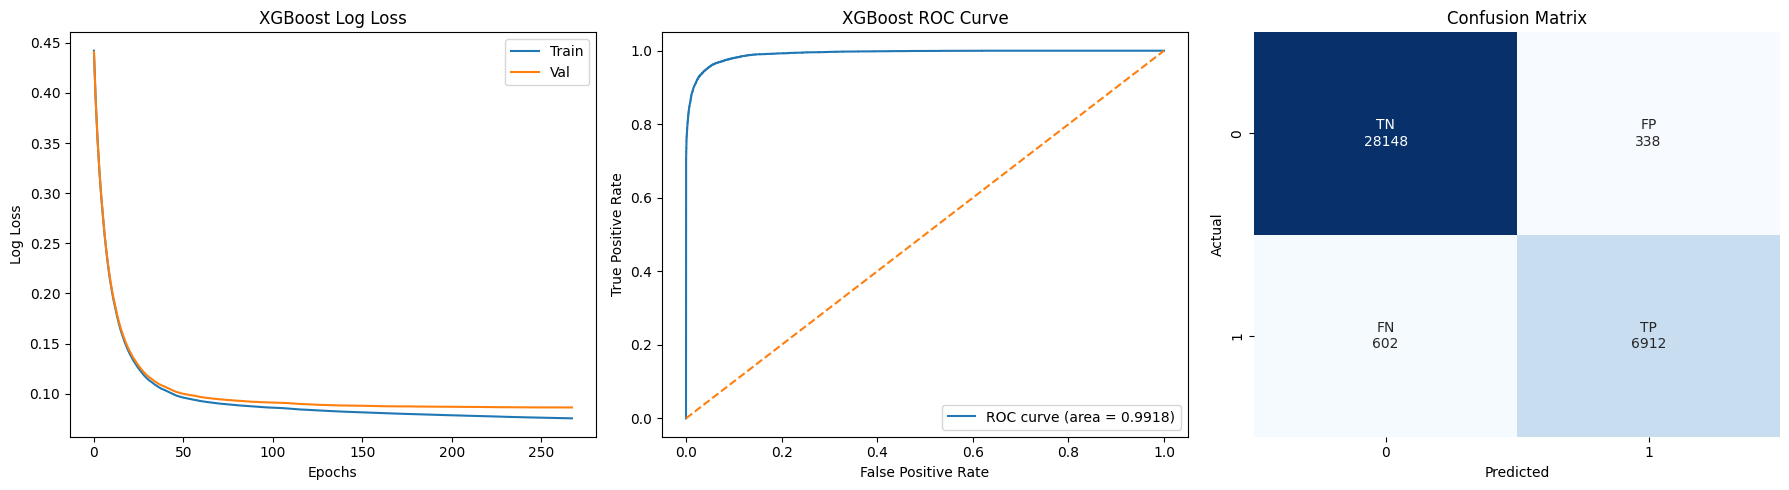

In [10]:
#train new model with only the top 15 features
x_train_top15 = x_train[feature_importance_list]
x_test_top15 = x_test[feature_importance_list]
model_top15 = XGBClassifier(**parameters)
model_top15.fit(x_train_top15, y_train, eval_set=[(x_train_top15, y_train), (x_test_top15, y_test)])
y_pred_top15 = model_top15.predict(x_test_top15)
print("Classification Report (Top 15 features):")
print(classification_report(y_test, y_pred_top15))
print("Confusion Matrix (Top 15 features):")
print(confusion_matrix(y_test, y_pred_top15))
print("Accuracy Score (Top 15 features):", accuracy_score(y_test, y_pred_top15))

#plot training loss, roc curve and confusion matrix with tp fp tn fn labels
results = model_top15.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.legend()

y_prob = model_top15.predict_proba(x_test_top15)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()

cm = confusion_matrix(y_test, y_pred)
labels = [['TN', 'FP'], ['FN', 'TP']]
annot = [[f"{l}\n{v}" for l, v in zip(row_l, row_v)] for row_l, row_v in zip(labels, cm)]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

In [13]:
#save the model
model_top15.save_model('saved_models/XGB_final.json')
# save used parameters to a text file
with open('saved_models/XGB_final_params.txt', 'w') as f:
    for key, value in parameters.items():
        f.write(f"{key}: {value}\n")
